<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [ ]:
%%capture install_output
%%bash
# Install textblob and download corpora
pip3 install wikipedia-api


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from textblob import TextBlob
import nltk
from sklearn.feature_extraction.text import CountVectorizer as BagOfWords
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
pd.options.display.max_columns = 100
from transformers import MarianMTModel, MarianTokenizer
import wikipediaapi

In [ ]:
df_1 = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv')
view = df_1.loc[df_1["name"]=="John Cena"]
view

,URI,name,text
29541,<http://dbpedia.org/resource/John_Cena>,John Cena,john felix anthony cena sin born april 23 1977...


In [ ]:
description_jc = df_1.at[29541, "text"]
description_jc

'john felix anthony cena sin born april 23 1977 is an american professional wrestler rapper and actor signed to wwe cena is the public face of wwe and has served as its franchise player since 2005 he is a polarizing figure among pro wrestling fans despite playing a heroic character for the majority of his careercena started his pro wrestling career in 1999 with ultimate pro wrestling where he held the upw heavyweight championship cena signed a developmental contract with the world wrestling federation wwf later renamed to wwe in 2001 debuting on the main roster in 2002 as of april 2015 cena has won 22 championships with a record 12 reigns as wwe championwwe world heavyweight champion three reigns as world heavyweight champion three reigns as wwe united states champion and a fourtime tag team champion two world tag team and two wwe tag team he also won the 2012 money in the bank ladder match and is a twotime royal rumble winner 2008 2013 he has the fourthhighest number of combined days 

In [ ]:
jc_blob = TextBlob(description_jc)
jc_blob.sentiment

Sentiment(polarity=0.11268939393939391, subjectivity=0.4375)

In [ ]:
df_1['text'] = df_1['text'].str.replace(r"(\n|'s|'| )+", ' ', regex=True)

In [ ]:
BoW =  BagOfWords(stop_words='english')
vector = BoW.fit_transform(df_1['text'])




In [ ]:
tf_idf_vec = TfidfTransformer()
tf_idf_jen = tf_idf_vec.fit_transform(vector)


In [ ]:
nn = NearestNeighbors().fit(tf_idf_jen)

john_cena_index = 29541
john_cena_vector = tf_idf_jen[john_cena_index]

distances, indices = nn.kneighbors(john_cena_vector, n_neighbors = 11)
closest_indices = indices.flatten()[1:]
closest_distances = distances.flatten()[1:]

distances

array([[0.        , 1.0799763 , 1.08017322, 1.08796181, 1.09928525,
        1.0996915 , 1.10479547, 1.10872242, 1.11349581, 1.1295769 ,
        1.1386729 ]])

In [ ]:
names = []

for a, b in zip(closest_distances, closest_indices):
    print(f"{a:.4f}: {df_1.at[b, "name"]}")
    names.append(df_1.at[b, "name"])

1.0800: Road Dogg
1.0802: The Miz
1.0880: Randy Orton
1.0993: CM Punk
1.0997: Dave Bautista
1.1048: Edge (wrestler)
1.1087: Daniel Bryan
1.1135: Melina Perez
1.1296: Gail Kim
1.1387: Charlie Haas


### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



In [ ]:
import re

person = 'John Cena'
def getpage(topic):
  wikip = wikipediaapi.Wikipedia(user_agent = 'foobar')
  page_ex = wikip.page(topic)
  wiki_text = page_ex.text
  wiki_text = (re.sub(r"(\n|'s|'| )+", " ", wiki_text))
  return wiki_text
jc_text = getpage(person)
jc_text_blob = TextBlob(jc_text)
jc_text_blob

TextBlob("John Felix Anthony Cena ( SEE-nə; born April 23, 1977) is an American actor, retired professional wrestler, and former rapper. He is signed to WWE as a brand ambassador. Cena wrestled for WWE for 24 years, becoming a record-setting 17-time world champion, before transitioning fully into his acting career. Cena began professional wrestling in 1999 and signed with the World Wrestling Federation in 2001 (renamed WWE in 2002), where he began in its then-developmental territory Ohio Valley Wrestling (OVW). After debuting on the main roster on WWE SmackDown! in 2002, he rose to prominence as a brash heel rapper, before becoming the company franchise player from the mid-2000s to the mid-2010s. He wrestled on a part-time schedule from 2017 until his retirement in 2025. His run as a face from 2003 to 2025 was the longest continuous portrayal of a heroic character in WWE history. Cena held numerous championships and accomplishments in WWE, including the WWE Championship a record 14 tim

In [ ]:
jc_text_blob.sentiment

Sentiment(polarity=0.06719290904984562, subjectivity=0.38064752524290135)

In [ ]:
wiki_ps = {}
wiki_ps["John Cena"] = jc_text

for n in names:
  wiki_ps[n] = getpage(n)
print(wiki_ps.keys())

dict_keys(['John Cena', 'Road Dogg', 'The Miz', 'Randy Orton', 'CM Punk', 'Dave Bautista', 'Edge (wrestler)', 'Daniel Bryan', 'Melina Perez', 'Gail Kim', 'Charlie Haas'])


In [ ]:
vector_bag = BoW.fit_transform(wiki_ps.values())
tf_idf_gen = tf_idf_vec.fit_transform(vector_bag)

nn = NearestNeighbors().fit(tf_idf_gen)

john_cena_index = 0
sent0 = tf_idf_gen[john_cena_index]

distances, indices = nn.kneighbors(sent0, n_neighbors = 11)
closest_indices_wiki = indices.flatten()[1:]
closest_distances_wiki = distances.flatten()[1:]

closest_distances_wiki

array([1.05497507, 1.10590616, 1.10811757, 1.11352789, 1.12539259,
       1.15810926, 1.23845959, 1.25932218, 1.27993976, 1.28079085])

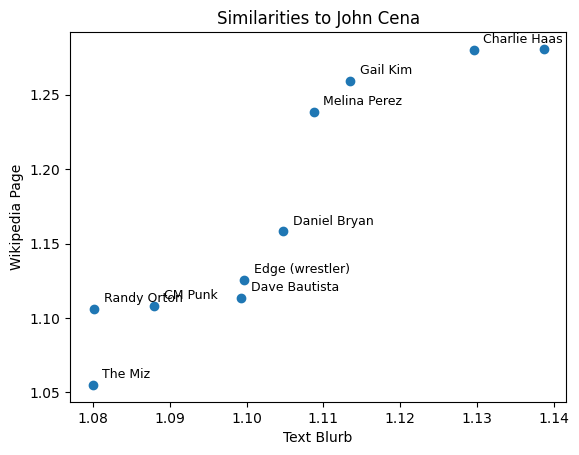

In [ ]:
plt.scatter(closest_distances, closest_distances_wiki)



for i, name in enumerate(names[1:]):
    plt.annotate(
        name,
        (closest_distances[i], closest_distances_wiki[i]),
        textcoords="offset points", # Tells matplotlib to offset the text by pixels
        xytext=(7, 5),               # Shift text 7 pixels right and 5 pixels up
        ha='left',                  # Align text to the left of the label box
        fontsize=9                  # Keep font size reasonable so it doesn't clutter
    )
plt.xlabel("Text Blurb")
plt.ylabel("Wikipedia Page")
plt.title("Similarities to John Cena")

plt.show()



### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [ ]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [ ]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [ ]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [ ]:
#@title Similarity Searcher

search_query = "pink" #@param {type:"string"}

# Run the filtering script
search = df_1[df_1['name'].str.lower().str.contains(search_query.lower(), na=False)]

if not search.empty:

  index = search.index.item()
  vector = tf_idf_jen[index]

  nn = NearestNeighbors().fit(tf_idf_jen)

  distances, indices = nn.kneighbors(vector, n_neighbors = 11)
  closest_indices = indices.flatten()[1:]
  closest_distances = distances.flatten()[1:]



  results = df_1.iloc[closest_indices][['name']]

  display(results)
else:
  print(f"No results found for '{search_query}'")

,name
6425,Barbra Streisand
317,Carrie Underwood
27787,Adele
24370,Britney Spears
28819,Rod Stewart
26581,Jay Sean
39535,Andrea Bocelli
11639,Pink (singer)
22287,Garth Brooks
15936,Bryan Adams
